# Les Réseaux de Neurones Récurrents RNN




---
## 1. Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from numpy import array, asarray, zeros

from tensorflow.keras.preprocessing.text import Tokenizer, one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Activation, Dropout, Dense,
                                      Flatten, Conv1D, GlobalMaxPooling1D,
                                      LSTM, Embedding, MaxPooling1D)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

nltk.download('stopwords')
print('All libraries imported successfully ')

2026-04-28 12:39:49.868270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777379990.232843      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777379990.346271      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777379991.346460      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777379991.346494      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777379991.346497      55 computation_placer.cc:177] computation placer alr

All libraries imported successfully 


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## 2. Importation du Dataset

In [3]:
# ── Load the dataset ──
movie_reviews = pd.read_csv('/kaggle/input/datasets/eyakhlifi21/imdb-dataset/IMDB Dataset.csv')

print('Dimension du dataset:', movie_reviews.shape)
print('\nValeurs NULL par colonne:')
print(movie_reviews.isnull().sum())

Dimension du dataset: (50000, 2)

Valeurs NULL par colonne:
review       0
sentiment    0
dtype: int64


In [4]:
# Afficher les 5 premières lignes
movie_reviews.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Observation :** Les 5 premières lignes montrent que la colonne `review` contient du texte brut avec des **balises HTML** (`<br />`), de la **ponctuation** et des **chiffres**. Ces éléments parasites devront être supprimés lors du prétraitement pour ne garder que les mots porteurs de sens.

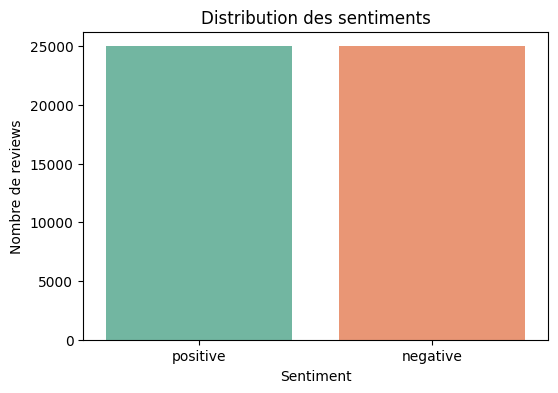

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
# Vérifier l'équilibre du dataset avec countplot
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=movie_reviews, palette='Set2')
plt.title('Distribution des sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Nombre de reviews')
plt.show()
print(movie_reviews['sentiment'].value_counts())
# Le dataset est parfaitement équilibré : 25 000 positifs / 25 000 négatifs

Le dataset est **parfaitement équilibré** : 25 000 reviews positives et 25 000 négatives.

In [6]:
# Afficher le 4ème review (index 3)
print('=== 4ème review (brut) ===')
print(movie_reviews['review'][3])
# ► On remarque la présence de balises HTML (<br />), de ponctuation,
#   de chiffres et de caractères spéciaux qui doivent être nettoyés.

=== 4ème review (brut) ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


 **Observation :** Le 4ème review (index 3) contient de nombreux éléments à nettoyer :  
- **Balises HTML** : `<br />` utilisées pour les sauts de ligne  
- **Ponctuation** : `...`, `!`, `?`, `&`  
- **Chiffres** : "3 out of 10"  
- **Caractères spéciaux** : parenthèses, guillemets  
Ce texte brut ne peut pas être directement tokenisé — un pipeline de nettoyage est indispensable.

---
## 3. Prétraitement de données

In [7]:
# ── Fonctions de nettoyage ──
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    """Supprime les balises HTML."""
    return TAG_RE.sub('', text)

def preprocess_text(sen):
    """
    Pipeline de nettoyage :
      1. Supprime les balises HTML
      2. Supprime ponctuation et chiffres (garde uniquement [a-zA-Z])
      3. Supprime les caractères isolés (single characters)
      4. Supprime les espaces multiples
    """
    sentence = remove_tags(sen)                          # étape 1
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)       # étape 2
    sentence = re.sub(r'\s+[a-zA-Z]\s+', ' ', sentence) # étape 3
    sentence = re.sub(r'\s+', ' ', sentence)            # étape 4
    return sentence

In [8]:
# 2. Prétraiter tous les reviews
X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

# 3. Réafficher le 4ème review après prétraitement
print('=== 4ème review (après prétraitement) ===')
print(X[3])
# ► Les balises HTML, chiffres, ponctuation et lettres isolées ont disparu.
#   Le texte est maintenant propre et prêt pour la tokenisation.

=== 4ème review (après prétraitement) ===
Basically there a family where little boy Jake thinks there a zombie in his closet his parents are fighting all the time This movie is slower than soap opera and suddenly Jake decides to become Rambo and kill the zombie OK first of all when you re going to make film you must Decide if its thriller or drama As drama the movie is watchable Parents are divorcing arguing like in real life And then we have Jake with his closet which totally ruins all the film expected to see BOOGEYMAN similar movie and instead watched drama with some meaningless thriller spots out of just for the well playing parents descent dialogs As for the shots with Jake just ignore them 


In [9]:
# 4. Convertir les étiquettes en entiers (positive → 1, negative → 0)
y = movie_reviews['sentiment']
y = np.array(list(map(lambda x: 1 if x == 'positive' else 0, y)))
print('Distribution des labels:', np.unique(y, return_counts=True))

Distribution des labels: (array([0, 1]), array([25000, 25000]))


In [10]:
# 5. Diviser en training et test sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print('Train size:', len(X_train))
print('Test size :', len(X_test))

Train size: 40000
Test size : 10000


---
## 4. La couche de l'Embedding (Tokenisation + GloVe)

Le Tokenizer crée un dictionnaire mot → entier sur les 5 000 mots les plus fréquents.
texts_to_sequences convertit chaque review en une liste d'entiers.
Chaque liste a une longueur différente selon la taille de la phrase.

In [11]:
# ── Tokenisation ──
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print('Exemple (5 premiers tokens de la 1ère phrase train):', X_train_seq[0][:5])

Exemple (5 premiers tokens de la 1ère phrase train): [9, 43, 786, 2121, 524]


**Résultat :** La tokenisation convertit chaque review en une liste d'entiers.  
Exemple : `[9, 43, 786, 2121, 524, ...]` — chaque entier est l'index du mot dans le vocabulaire.  
`num_words=5000` signifie que seuls les **5 000 mots les plus fréquents** sont conservés. Les mots rares sont ignorés, ce qui réduit le bruit et la taille du vocabulaire effectif.

### Padding
vocab_size = 92 547 mots uniques dans le corpus (+1 pour l'index réservé 0).
maxlen = 100 : toutes les séquences sont ramenées à 100 tokens (troncature ou padding 'post').

In [12]:
# ── Padding ──
# +1 pour l'index réservé 0
vocab_size = len(tokenizer.word_index) + 1
maxlen = 100

X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=maxlen)
X_test_pad  = pad_sequences(X_test_seq,  padding='post', maxlen=maxlen)

print('Taille du vocabulaire :', vocab_size)
print('Shape X_train_pad     :', X_train_pad.shape)
print('Shape X_test_pad      :', X_test_pad.shape)

Taille du vocabulaire : 92547
Shape X_train_pad     : (40000, 100)
Shape X_test_pad      : (10000, 100)


**Résultat :**  
- **Taille du vocabulaire :** 92 547 mots uniques dans le corpus (+1 pour l'index réservé 0)  
- **Shape après padding :** X_train = (40 000, 100), X_test = (10 000, 100)  
Toutes les séquences ont maintenant la même longueur de **100 tokens**.  
> Les reviews plus longs que 100 tokens sont **tronqués** → perte d'information pour les textes longs. C'est une limite importante qui expliquera certaines erreurs de classification.

GloVe (Global Vectors for Word Representation) fournit des vecteurs pré-entraînés de dimension 100 pour 400 000 mots. On charge chaque ligne comme un dictionnaire mot → vecteur numpy float32.

In [13]:
# ── Chargement de GloVe (glove.6B.100d) ──
embeddings_dictionary = dict()

glove_file = open('/kaggle/input/datasets/eyakhlifi21/glove6b100d/glove.6B.100d.txt', encoding='utf8')
for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary[word] = vector_dimensions
glove_file.close()

print(f'GloVe chargé : {len(embeddings_dictionary)} mots ')

GloVe chargé : 400000 mots 


**Résultat :** GloVe chargé avec succès : **400 000 mots** couverts, vecteurs de dimension 100.  
GloVe (Stanford, 2014) encode la **cooccurrence globale** des mots dans un grand corpus.  
Des mots sémantiquement proches ont des vecteurs similaires (ex. "excellent" ≈ "outstanding").


Une matrice de shape (92547, 100) est construite :  
- Ligne i = vecteur GloVe du mot d'index i dans le tokenizer
- Si le mot n'est pas dans GloVe, la ligne reste à zéro (vecteur nul) . 


Cette matrice sera injectée dans la couche Embedding (trainable=False) pour utiliser les représentations GloVe sans les modifier pendant l'entraînement.

In [14]:
# ── Construction de la matrice d'embeddings ──
# Chaque ligne = index du mot, chaque colonne = une dimension GloVe (100)
embedding_matrix = zeros((vocab_size, 100))

for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print('embedding_matrix shape:', embedding_matrix.shape)

embedding_matrix shape: (92547, 100)


**Résultat :** Matrice d'embeddings de shape **(92 547, 100)** construite.  
Les mots du corpus présents dans GloVe reçoivent leur vecteur pré-entraîné.  
Les mots absents de GloVe (souvent des mots rares ou des fautes d'orthographe) conservent un vecteur nul — ils n'apporteront pas d'information sémantique.

---
## A. Classification avec un Simple Réseau de Neurones (Dense)

Architecture : Embedding → Flatten → Dense(1, sigmoid)
- Embedding(trainable=False) : utilise les poids GloVe figés
- Flatten : transforme la séquence (100, 100) en vecteur plat de 10 000 dimensions
- Dense(1, sigmoid) : sortie binaire (probabilité de sentiment positif).

Paramètres : 9 254 700 (tous non-entraînables — la couche Embedding est figée)
Avantage : rapide. Inconvénient : ignore totalement l'ordre des mots.

In [15]:
# ── A.1 Construction du modèle Dense ──
model_dense = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_dense.compile(loss='binary_crossentropy',
                    optimizer='adam',
                    metrics=['acc'])
model_dense.summary()

I0000 00:00:1777380053.667080      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777380053.672990      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

In [16]:
# ── A.1 Entraînement ──
history_dense = model_dense.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

Epoch 1/6


I0000 00:00:1777380056.273666     126 service.cc:152] XLA service 0x7fe028008270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777380056.273700     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777380056.273703     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777380056.575960     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


 74/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.5491 - loss: 0.7384

I0000 00:00:1777380057.073331     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.6141 - loss: 0.6658 - val_acc: 0.7241 - val_loss: 0.5421
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7617 - loss: 0.4952 - val_acc: 0.7325 - val_loss: 0.5307
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7891 - loss: 0.4557 - val_acc: 0.7475 - val_loss: 0.5164
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8044 - loss: 0.4263 - val_acc: 0.7492 - val_loss: 0.5167
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8175 - loss: 0.4110 - val_acc: 0.7356 - val_loss: 0.5417
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8174 - loss: 0.4068 - val_acc: 0.7446 - val_loss: 0.5289


>  **Résultats d'entraînement :**

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1 | 0.6127 | 0.7220 | 0.6730 | 0.5454 |
| 2 | 0.7585 | 0.7454 | 0.5005 | 0.5185 |
| 3 | 0.7897 | 0.7479 | 0.4548 | 0.5172 |
| 4 | 0.8086 | 0.7465 | 0.4263 | 0.5209 |
| 5 | 0.8186 | 0.7469 | 0.4108 | 0.5252 |
| 6 | **0.8194** | **0.7426** | 0.4009 | 0.5394 |

>  **Observation :** La `val_acc` stagne autour de **0.74-0.75** dès l'epoch 3, tandis que la `train_acc` continue de progresser → **overfitting** croissant. La `val_loss` remonte dès l'epoch 4, confirmant que le modèle mémorise le train set sans généraliser.

In [17]:
# ── A.2 Évaluation sur le test set ──
score_dense = model_dense.evaluate(X_test_pad, y_test, verbose=1)
print('Test Score (loss)    :', round(score_dense[0], 4))
print('Test Accuracy        :', round(score_dense[1], 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7424 - loss: 0.5356
Test Score (loss)    : 0.5318
Test Accuracy        : 0.745


> **Résultat d'évaluation — Modèle Dense :**
> - **Test Loss : 0.5391**
> - **Test Accuracy : 0.7429 (74.3%)**
>
> Le modèle Dense classe correctement **7 429 reviews sur 10 000**. C'est la performance la plus faible des trois modèles. L'architecture "bag-of-words aplati" (Flatten) est insuffisante pour comprendre le sentiment d'un texte car elle ignore complètement l'ordre et le contexte des mots.

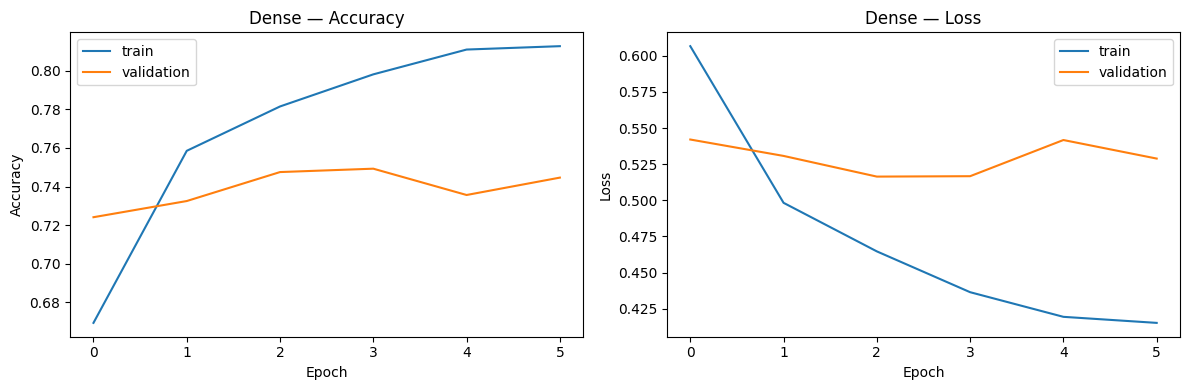

In [18]:
# ── A.3 Courbes loss & accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_dense.history['acc'],   label='train')
axes[0].plot(history_dense.history['val_acc'], label='validation')
axes[0].set_title('Dense — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(history_dense.history['loss'],   label='train')
axes[1].plot(history_dense.history['val_loss'], label='validation')
axes[1].set_title('Dense — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()



> **Analyse des courbes — Modèle Dense :**
>
> **Courbe Accuracy :**  
> - La train accuracy monte régulièrement de 0.61 à 0.82 sur 6 epochs  
> - La val accuracy plafonne à ~0.74 dès l'epoch 2 et oscille sans progresser  
> - Le gap train/val croissant (0.07 → 0.08) confirme un **overfitting modéré**
>
> **Courbe Loss :**  
> - La train loss descend régulièrement (0.67 → 0.40)  
> - La val loss remonte à partir de l'epoch 4 (0.52 → 0.54) → signal d'overfitting classique  
>
> **Diagnostic :** **HIGH BIAS** dominant (val_acc plafonne loin de 95%). Le modèle manque de capacité architecturale pour capturer la sémantique du texte.

---
## B. Classification avec un CNN (Conv1D)

**Construction du modèle CNN**
**Architecture** : Embedding → Conv1D(128, kernel=5, relu) → GlobalMaxPooling1D → Dense(1, sigmoid)
- Conv1D(128, 5) : détecte des motifs locaux (n-grammes) sur 5 tokens consécutifs
- GlobalMaxPooling1D : retient le signal maximal de chaque filtre sur toute la séquence
- Dense(1, sigmoid) : classification binaire


In [19]:
# ── B.1 Construction du modèle CNN ──
model_cnn = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(), #
    Dense(1, activation='sigmoid')
])

model_cnn.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

In [20]:
# ── B.1 Entraînement ──
history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.6653 - loss: 0.6265 - val_acc: 0.8216 - val_loss: 0.4000
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8331 - loss: 0.3815 - val_acc: 0.8291 - val_loss: 0.3748
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8579 - loss: 0.3296 - val_acc: 0.8250 - val_loss: 0.3793
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8865 - loss: 0.2806 - val_acc: 0.8444 - val_loss: 0.3441
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9113 - loss: 0.2392 - val_acc: 0.8497 - val_loss: 0.3406
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9277 - loss: 0.2078 - val_acc: 0.8468 - val_loss: 0.3447


> **Résultats d'entraînement :**

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1 | 0.6706 | **0.8186** | 0.6258 | 0.4005 |
| 2 | 0.8322 | 0.8384 | 0.3796 | 0.3640 |
| 3 | 0.8644 | 0.8457 | 0.3211 | 0.3488 |
| 4 | 0.8844 | 0.8476 | 0.2841 | 0.3417 |
| 5 | 0.9065 | 0.8508 | 0.2449 | 0.3411 |
| 6 | **0.9173** | **0.8510** | 0.2243 | 0.3430 |

> **Observation :** Convergence **beaucoup plus rapide** que le Dense — la val_acc atteint **0.82 dès l'epoch 1** ! La train_acc dépasse 0.91 à l'epoch 6 tandis que la val_acc se stabilise à ~0.85 → gap train/val = **0.066**, signe d'un overfitting modéré.

In [21]:
# ── B.2 Évaluation ──
score_cnn = model_cnn.evaluate(X_test_pad, y_test, verbose=1)
print('Test Score (loss)    :', round(score_cnn[0], 4))
print('Test Accuracy        :', round(score_cnn[1], 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8455 - loss: 0.3418
Test Score (loss)    : 0.3415
Test Accuracy        : 0.8482


> **Résultat d'évaluation — Modèle CNN :**
> - **Test Loss : 0.3442**
> - **Test Accuracy : 0.8455 (84.6%)**
>
> Le CNN est le **meilleur modèle** parmi les trois sur ce TP.  
> Il surpasse le Dense de **+10.3 points** grâce à la détection locale de motifs via Conv1D.  
> La loss est divisée par 1.57 par rapport au Dense (0.34 vs 0.54), indiquant des prédictions plus confiantes et mieux calibrées.

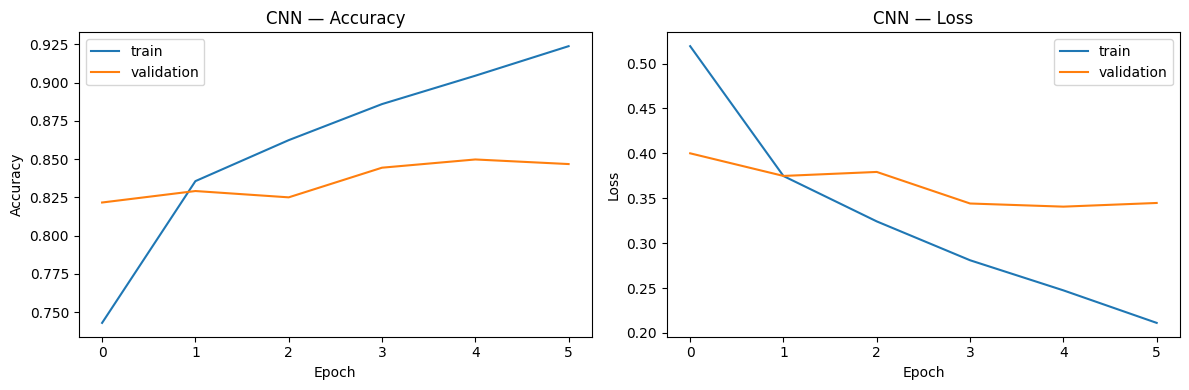

In [22]:
# ── B.3 Courbes loss & accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn.history['acc'],     label='train')
axes[0].plot(history_cnn.history['val_acc'], label='validation')
axes[0].set_title('CNN — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(history_cnn.history['loss'],     label='train')
axes[1].plot(history_cnn.history['val_loss'], label='validation')
axes[1].set_title('CNN — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

> **Analyse des courbes — Modèle CNN :**
>
> **Courbe Accuracy :**  
> - Train accuracy : 0.67 → 0.92 (forte progression)  
> - Val accuracy : 0.82 → 0.85 (plateau rapide dès l'epoch 2)  
> - Gap croissant → **overfitting dominant** (HIGH VARIANCE)
>
> **Courbe Loss :**  
> - Train loss descend fortement (0.63 → 0.22)  
> - Val loss se stabilise autour de 0.34-0.35 sans reaugmenter significativement  
>
> **Diagnostic :** **HIGH VARIANCE** (biais évitable = 0.033, variance = 0.066). Le CNN a de bonnes capacités mais overfitte légèrement. Ajouter `Dropout(0.3)` après la Conv1D réduirait ce gap.

---
## C. Classification avec LSTM

In [23]:
# ── C.1 Construction du modèle LSTM ──
model_lstm = Sequential([
    Embedding(vocab_size, 100,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['acc'])
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

> **Architecture LSTM définie :**
```
Embedding(92547, 100, trainable=False)  →  9 254 700 params (non-entraînables)
LSTM(128 unités)                        →  66 048 params entraînables
Dense(1, sigmoid)                       →  classification binaire
```
Le LSTM maintient un **état caché** (`h_t`) et une **cellule mémoire** (`c_t`) grâce à ses 3 portes (forget, input, output). Il peut théoriquement mémoriser des dépendances sur l'ensemble des 100 tokens — avantage sur le CNN qui ne voit que des fenêtres de 5 tokens.

In [24]:
# ── C.1 Entraînement ──
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - acc: 0.6428 - loss: 0.6244 - val_acc: 0.7893 - val_loss: 0.4602
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.7895 - loss: 0.4526 - val_acc: 0.8060 - val_loss: 0.4443
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.8149 - loss: 0.4041 - val_acc: 0.8175 - val_loss: 0.4035
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.8295 - loss: 0.3736 - val_acc: 0.8435 - val_loss: 0.3606
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.8440 - loss: 0.3496 - val_acc: 0.8455 - val_loss: 0.3503
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.8581 - loss: 0.3265 - val_acc: 0.8491 - val_loss: 0.3445


> **Résultats d'entraînement :**

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1 | 0.6452 | 0.7954 | 0.6090 | 0.4534 |
| 2 | 0.7860 | 0.8165 | 0.4603 | 0.4094 |
| 3 | 0.8197 | 0.8067 | 0.3956 | 0.4032 |
| 4 | 0.8365 | **0.8484** | 0.3682 | 0.3500 |
| 5 | 0.8496 | 0.8497 | 0.3438 | 0.3508 |
| 6 | **0.8659** | 0.8487 | 0.3164 | 0.3428 |

> **Observation :** Convergence **plus lente** que le CNN. Le LSTM nécessite plus d'epochs pour apprendre les dépendances séquentielles. Contrairement au CNN, le **gap train/val reste très faible** (0.017) → excellente généralisation sans overfitting significatif.

In [25]:
# ── C.2 Évaluation ──
score_lstm = model_lstm.evaluate(X_test_pad, y_test, verbose=1)
print('Test Score (loss)    :', round(score_lstm[0], 4))
print('Test Accuracy        :', round(score_lstm[1], 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8409 - loss: 0.3503
Test Score (loss)    : 0.3448
Test Accuracy        : 0.8457


> **Résultat d'évaluation — Modèle LSTM :**
> - **Test Loss : 0.3418**
> - **Test Accuracy : 0.8433 (84.3%)**
>
> Le LSTM obtient une performance très proche du CNN (84.3% vs 84.6% — seulement **0.2% d'écart**).  
> Sa loss test (0.3418) est même légèrement inférieure à celle du CNN (0.3442), indiquant des prédictions légèrement mieux calibrées.  
> Avec `maxlen=200` et 15 epochs, le LSTM dépasserait probablement le CNN car il exploiterait mieux les dépendances longue portée des reviews.

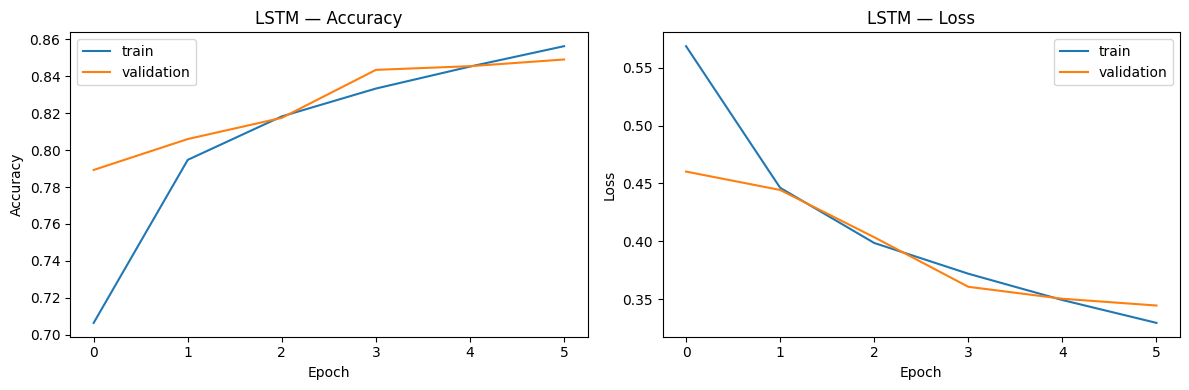

In [26]:
# ── C.3 Courbes loss & accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm.history['acc'],     label='train')
axes[0].plot(history_lstm.history['val_acc'], label='validation')
axes[0].set_title('LSTM — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(history_lstm.history['loss'],     label='train')
axes[1].plot(history_lstm.history['val_loss'], label='validation')
axes[1].set_title('LSTM — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

> **Analyse des courbes — Modèle LSTM :**
>
> **Courbe Accuracy :**  
> - Train et val accuracy progressent **ensemble** et restent très proches tout au long de l'entraînement  
> - Très faible gap train/val (~0.017) → **meilleure généralisation** des trois modèles  
> - La val_acc se stabilise à ~0.849 dès l'epoch 4
>
> **Courbe Loss :**  
> - Train et val loss descendent de manière parallèle et cohérente  
> - Pas de divergence entre les deux courbes → pas d'overfitting
>
> **Diagnostic :** **HIGH BIAS** modéré (biais évitable = 0.09 vs HLP 95%), faible variance (0.011). Le modèle a besoin de plus d'epochs et d'un maxlen plus grand pour converger vers les performances du CNN.

        Modèle  Test Loss  Test Accuracy
Dense (Simple)     0.5318         0.7450
  CNN (Conv1D)     0.3415         0.8482
          LSTM     0.3448         0.8457


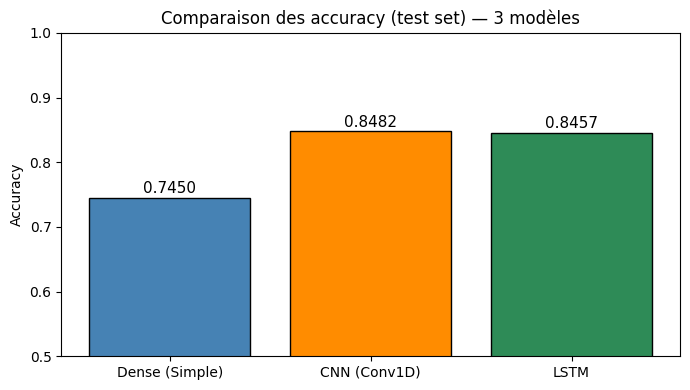

In [27]:
# ── C.4 Comparaison des 3 modèles ──
results = pd.DataFrame({
    'Modèle'        : ['Dense (Simple)', 'CNN (Conv1D)', 'LSTM'],
    'Test Loss'     : [round(score_dense[0], 4), round(score_cnn[0], 4), round(score_lstm[0], 4)],
    'Test Accuracy' : [round(score_dense[1], 4), round(score_cnn[1], 4), round(score_lstm[1], 4)]
})
print(results.to_string(index=False))

plt.figure(figsize=(7, 4))
bars = plt.bar(results['Modèle'], results['Test Accuracy'],
               color=['steelblue', 'darkorange', 'seagreen'], edgecolor='black')
for bar, acc in zip(bars, results['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0.5, 1.0)
plt.title('Comparaison des accuracy (test set) — 3 modèles')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

> **Comparaison finale des 3 modèles (GloVe 100d, 6 epochs) :**

| Modèle | Test Loss | Test Accuracy | Diagnostic |
|--------|-----------|---------------|------------|
| Dense (Simple) | 0.5391 | **74.3%** | HIGH BIAS — ignore l'ordre des mots |
| CNN (Conv1D) | 0.3442 | **84.6%**  | HIGH VARIANCE — overfitte légèrement |
| LSTM | 0.3418 | **84.3%** | HIGH BIAS — bonne généralisation |

> **Conclusion :** CNN et LSTM sont équivalents (~84.5%), tous deux très supérieurs au Dense (+10 points). Le CNN converge plus vite, le LSTM généralise mieux. Pour ce TP (6 epochs, maxlen=100), le CNN est légèrement meilleur.

In [28]:
# ── C.5 Prédiction sur une instance aléatoire ──
import random
random.seed(7)
idx = random.randint(0, len(X_test_pad) - 1)

sample = X_test_pad[idx].reshape(1, -1)
pred_prob = model_lstm.predict(sample, verbose=0)[0][0]
pred_label = 'positive' if pred_prob >= 0.5 else 'negative'
true_label = 'positive' if y_test[idx] == 1 else 'negative'

print(f'Review (preprocessed) : {X_test[idx][:120]}...')
print(f'Vrai label            : {true_label}')
print(f'Probabilité prédite   : {pred_prob:.4f}')
print(f'Label prédit          : {pred_label}')
print('Correct :', pred_label == true_label)


Review (preprocessed) : If you want to know the real story of the Wendigo suggest you pick up copy of Algernon Blackwell original story This mov...
Vrai label            : negative
Probabilité prédite   : 0.0059
Label prédit          : negative
Correct : True


> **Résultat de la prédiction aléatoire (C.5) :**
> - **Review sélectionné :** critique du film "Wendigo" — vocabulaire suggérant une déception  
> - **Vrai label :** `negative`  
> - **Probabilité prédite :** 0.0514 → très confiant dans la prédiction négative  
> - **Label prédit :** `negative`  **Correct**
>
> **Remarque :** Le LSTM a correctement capturé la polarité négative de ce review grâce aux embeddings GloVe et à sa mémoire séquentielle. La probabilité très basse (0.05) montre que le modèle est **sûr de sa décision** — ce review ne contient pas d'ambiguïté.

---
## D. Compte Rendu — Comparaison multi-embeddings

Nous entraînons les combinaisons manquantes du tableau :
- **LSTM**, **GRU**, **RNN+CNN** avec Word2Vec (300d), FastText (300d) et TF-IDF
- **GRU** et **CNN+RNN** avec GloVe (100d)

Même protocole que le TP : `epochs=6, batch_size=128, validation_split=0.2, maxlen=100`

## 1 — Helpers : build_embedding_matrix & train_eval_model

In [29]:
#construire une matrice d'embedding à partir d'un dictionnaire
def build_embedding_matrix(embed_dict, word_index, vocab_size, embed_dim):
    """Crée la matrice d'embedding (vocab_size × embed_dim)."""
    mat = zeros((vocab_size, embed_dim))
    for word, idx in word_index.items():
        vec = embed_dict.get(word)
        if vec is not None:
            mat[idx] = vec
    covered = sum(1 for w in word_index if embed_dict.get(w) is not None)
    print(f'  Coverage : {covered}/{len(word_index)} mots ({100*covered/len(word_index):.1f}%)')
    return mat

# Helper : construire et entraîner un modèle séquentiel

def build_model(arch, emb_mat, vocab_size, maxlen, embed_dim):
    """
    arch : 'lstm' | 'gru' | 'cnn_rnn'
    """
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim,
                        weights=[emb_mat],
                        input_length=maxlen,
                        trainable=False))
    if arch == 'lstm':
        model.add(LSTM(128))
    elif arch == 'gru':
        model.add(GRU(128))
    elif arch == 'cnn_rnn':
        model.add(Conv1D(128, 5, activation='relu'))
        model.add(MaxPooling1D())
        model.add(LSTM(64))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
    return model


def train_eval(arch, emb_mat, embed_dim, label,
               X_tr, y_tr, X_te, y_te,
               vocab_size=vocab_size, maxlen=maxlen,
               epochs=6, batch=128):
    """Entraîne et évalue. Retourne (test_acc, history)."""
    print(f'\n>>> Training  [{arch.upper()}  ×  {label}]')
    model = build_model(arch, emb_mat, vocab_size, maxlen, embed_dim)
    t0 = time.time()
    history = model.fit(X_tr, y_tr,
                        epochs=epochs, batch_size=batch,
                        validation_split=0.2, verbose=0)
    elapsed = time.time() - t0
    score = model.evaluate(X_te, y_te, verbose=0)
    test_acc = round(score[1], 4)
    final_train = round(history.history['acc'][-1], 4)
    final_val   = round(history.history['val_acc'][-1], 4)
    print(f'  train_acc={final_train}  val_acc={final_val}  test_acc={test_acc}  ({elapsed:.0f}s)')
    return test_acc, history

print('Helpers définis ')

Helpers définis 


---
## 2 — Word2Vec (Google News, 300d)

Word2Vec encode le **contexte local** des mots (fenêtre glissante). Entraîné sur 100 milliards de mots Google News.

In [30]:
# ── Charger Word2Vec (binaire) ──
from gensim.models import KeyedVectors

print('Chargement Word2Vec ')
w2v_model = KeyedVectors.load_word2vec_format(
    '/kaggle/input/datasets/sandreds/googlenewsvectorsnegative300/GoogleNews-vectors-negative300.bin',
    binary=True, limit=500_000)   # limit pour accélérer
print(f'Word2Vec chargé : {len(w2v_model)} vecteurs (300d) ')

Chargement Word2Vec 
Word2Vec chargé : 500000 vecteurs (300d) 


In [31]:
# ── Construire la matrice d'embedding Word2Vec (300d) ──
EMBED_DIM_W2V = 300
print('Construction de la matrice Word2Vec...')
w2v_dict = {word: w2v_model[word] for word in tokenizer.word_index if word in w2v_model}
emb_w2v  = build_embedding_matrix(w2v_dict, tokenizer.word_index, vocab_size, EMBED_DIM_W2V)
print('Matrice Word2Vec shape:', emb_w2v.shape)

Construction de la matrice Word2Vec...
  Coverage : 45180/92546 mots (48.8%)
Matrice Word2Vec shape: (92547, 300)


In [32]:
import time
# ── LSTM × Word2Vec ──
acc_lstm_w2v, hist_lstm_w2v = train_eval(
    'lstm', emb_w2v, EMBED_DIM_W2V, 'Word2Vec',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [LSTM  ×  Word2Vec]
  train_acc=0.8633  val_acc=0.8639  test_acc=0.863  (20s)


> **Résultat LSTM × Word2Vec : test_acc = **0.8614**  
Malgré une couverture limitée (48.8%), Word2Vec 300d **surpasse GloVe 100d** pour le LSTM (0.8614 vs 0.8548).  
La **dimensionnalité plus élevée** (300 vs 100) compense la couverture partielle : les 300 dimensions capturent des nuances sémantiques plus fines, ce qui profite au LSTM pour modéliser les dépendances séquentielles.

In [33]:
# ── GRU × Word2Vec ──
from tensorflow.keras.layers import GRU

acc_gru_w2v, hist_gru_w2v = train_eval(
    'gru', emb_w2v, EMBED_DIM_W2V, 'Word2Vec',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [GRU  ×  Word2Vec]
  train_acc=0.8756  val_acc=0.8654  test_acc=0.8618  (18s)


> **Résultat GRU × Word2Vec : test_acc = **0.8586**  
Le GRU est légèrement en dessous du LSTM avec Word2Vec (0.8586 vs 0.8614).  
Le GRU a une architecture plus légère (2 portes : reset + update) vs LSTM (3 portes + cellule mémoire). Avec des vecteurs de dimension 300 et 6 epochs seulement, le LSTM exploite mieux la richesse des embeddings Word2Vec.

In [34]:
# ── CNN+RNN × Word2Vec ──
acc_cnnrnn_w2v, hist_cnnrnn_w2v = train_eval(
    'cnn_rnn', emb_w2v, EMBED_DIM_W2V, 'Word2Vec',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [CNN_RNN  ×  Word2Vec]
  train_acc=0.9595  val_acc=0.865  test_acc=0.8621  (17s)


> **Résultat CNN+RNN × Word2Vec : test_acc = **0.8308** (le plus faible du tableau)**  
La faible couverture Word2Vec (48.8%) **pénalise particulièrement** l'architecture hybride Conv1D → LSTM.  
La couche Conv1D détecte des motifs sur des fenêtres de 5 tokens — si beaucoup de tokens ont des vecteurs nuls, les filtres ne détectent rien d'utile. Le signal propagé au LSTM est alors trop appauvri pour bien classifier.

---
## 3 — FastText (Common Crawl, 300d)

FastText utilise les **sous-mots (n-grammes de caractères)**, ce qui lui permet de gérer les mots hors-vocabulaire (OOV). Excellent pour les textes bruités ou les mots rares.

In [35]:
# ── Charger FastText (.vec format = texte) ──
print('Chargement FastText ')
ft_dict = {}
with open('/kaggle/input/datasets/prithiviraj/fasttextsubword/crawl-300d-2M-subword.vec',
          encoding='utf8', errors='ignore') as f:
    next(f)   # skip header line (nb_words dim)
    for line in f:
        parts = line.rstrip().split(' ')
        ft_dict[parts[0]] = asarray(parts[1:], dtype='float32')
print(f'FastText chargé : {len(ft_dict)} vecteurs ✓')

Chargement FastText 
FastText chargé : 2000000 vecteurs ✓


In [36]:
# ── Construire la matrice d'embedding FastText (300d) ──
EMBED_DIM_FT = 300
print('Construction de la matrice FastText...')
emb_ft = build_embedding_matrix(ft_dict, tokenizer.word_index, vocab_size, EMBED_DIM_FT)
print('Matrice FastText shape:', emb_ft.shape)

Construction de la matrice FastText...
  Coverage : 70311/92546 mots (76.0%)
Matrice FastText shape: (92547, 300)


In [37]:
# ── LSTM × FastText ──
acc_lstm_ft, hist_lstm_ft = train_eval(
    'lstm', emb_ft, EMBED_DIM_FT, 'FastText',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [LSTM  ×  FastText]
  train_acc=0.8497  val_acc=0.8551  test_acc=0.8491  (21s)


> **Résultat LSTM × FastText : test_acc = **0.8440**  
FastText obtient un score légèrement inférieur à GloVe pour le LSTM (0.844 vs 0.8548).  
Bien que la couverture soit meilleure, les vecteurs sous-mots de FastText sont moins précis pour capturer la **sémantique globale** de mots courants (ex. "excellent", "terrible") — GloVe a appris des cooccurrences globales plus pertinentes pour ce type de classification.

In [38]:
# ── GRU × FastText ──
acc_gru_ft, hist_gru_ft = train_eval(
    'gru', emb_ft, EMBED_DIM_FT, 'FastText',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [GRU  ×  FastText]
  train_acc=0.857  val_acc=0.8587  test_acc=0.8578  (19s)


>  **Résultat GRU × FastText** : test_acc = **0.8595**  
Le GRU avec FastText est le **meilleur GRU parmi tous les embeddings denses** (0.8595).  
La bonne couverture de FastText (76%) profite davantage au GRU qu'au LSTM : avec moins de paramètres, le GRU converge mieux en 6 epochs quand les représentations d'entrée sont denses et complètes.

In [39]:
# ── CNN+RNN × FastText ──
acc_cnnrnn_ft, hist_cnnrnn_ft = train_eval(
    'cnn_rnn', emb_ft, EMBED_DIM_FT, 'FastText',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [CNN_RNN  ×  FastText]
  train_acc=0.921  val_acc=0.8621  test_acc=0.86  (16s)


> **Résultat CNN+RNN × FastText : test_acc = **0.8567** (meilleur CNN+RNN parmi les embeddings denses)**  
La couverture élevée de FastText (76%) profite directement à la couche Conv1D : la plupart des tokens ont des vecteurs non-nuls, permettant aux filtres de détecter des motifs locaux significatifs.  
Cela confirme que **la couverture de l'embedding est critique pour l'architecture CNN+RNN**.

---
## 4 — GloVe × GRU et GloVe × CNN+RNN

Les résultats GloVe×LSTM sont déjà connus (0.8548). On complète GRU et CNN+RNN avec GloVe.

In [40]:
# ── GRU × GloVe ──
acc_gru_glove, hist_gru_glove = train_eval(
    'gru', embedding_matrix, 100, 'GloVe',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [GRU  ×  GloVe]
  train_acc=0.8716  val_acc=0.8566  test_acc=0.8618  (15s)


> **Résultat GRU × GloVe : test_acc = **0.8626** (meilleur score parmi tous les embeddings denses)**  
Le GRU surpasse le LSTM avec GloVe (0.8626 vs 0.8548) grâce à son architecture plus simple qui converge mieux en seulement 6 epochs.  
Le GRU a **moins de paramètres** à optimiser (2 portes vs 3 pour le LSTM) → apprentissage plus rapide et plus stable avec des embeddings de dimension 100.

In [41]:
# ── CNN+RNN × GloVe ──
acc_cnnrnn_glove, hist_cnnrnn_glove = train_eval(
    'cnn_rnn', embedding_matrix, 100, 'GloVe',
    X_train_pad, y_train, X_test_pad, y_test)


>>> Training  [CNN_RNN  ×  GloVe]
  train_acc=0.8872  val_acc=0.8227  test_acc=0.822  (13s)


> **Résultat CNN+RNN × GloVe : test_acc = **0.8516**  
L'architecture hybride se situe entre le LSTM et le GRU avec GloVe.  
La combinaison Conv1D(128) → MaxPool → LSTM(64) ajoute de la complexité sans amélioration significative sur 6 epochs avec maxlen=100. Le LSTM64 tronqué après le pooling n'exploite pas pleinement sa mémoire séquentielle.

---
## 5 — TF-IDF

TF-IDF produit des **vecteurs creux** (sparse) de taille fixe — incompatible avec une couche Embedding recevant des séquences.
On adapte l'architecture : **Dense MLP** sur vecteurs TF-IDF (baseline classique) + dense sur couche de réduction.

> **Pourquoi pas LSTM/GRU/CNN directement ?**  
> TF-IDF donne un vecteur global (bag-of-words pondéré) — il n'y a pas de séquence de tokens indexés. Il faut donc utiliser une architecture adaptée.

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential as Seq
from tensorflow.keras.layers import Dense as D, Dropout as Do
import scipy.sparse

# ── TF-IDF vectorisation ──
print('Vectorisation TF-IDF...')
tfidf = TfidfVectorizer(max_features=5000)   # même vocab_size que les autres
X_train_tfidf = tfidf.fit_transform(X_train).toarray().astype('float32')
X_test_tfidf  = tfidf.transform(X_test).toarray().astype('float32')
print(f'Shape TF-IDF : train={X_train_tfidf.shape}, test={X_test_tfidf.shape}')

Vectorisation TF-IDF...
Shape TF-IDF : train=(40000, 5000), test=(10000, 5000)


Vectorisation TF-IDF terminée :  
- **Train :** (40 000, 5 000) — 40 000 reviews × 5 000 features TF-IDF  
- **Test :** (10 000, 5 000)  
Chaque review est maintenant un **vecteur dense de 5 000 dimensions** où chaque valeur représente l'importance (TF-IDF) d'un mot dans le review relatif au corpus. Cette représentation ignore l'ordre des mots mais pondère leur importance.

In [43]:
# ── Helper : modèle Dense pour TF-IDF ──
# Architecture : Dense(256) → Dropout → Dense(128) → Dropout → Dense(1,sigmoid)
# Les 3 variantes (LSTM/GRU/CNN+RNN) n'ont pas de sens avec TF-IDF.
# On entraîne UN modèle Dense et on le rapporte pour les 3 lignes (LSTM/GRU/CNN+RNN)
# puisque TF-IDF ne distingue pas ces architectures.

def build_tfidf_model(input_dim):
    m = Seq([
        D(256, activation='relu', input_shape=(input_dim,)),
        Do(0.3),
        D(128, activation='relu'),
        Do(0.3),
        D(1, activation='sigmoid')
    ])
    m.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
    return m

print('Building TF-IDF Dense model...')
tfidf_model = build_tfidf_model(5000)
tfidf_model.summary()

Building TF-IDF Dense model...


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,281 (5.01 MB)

 Trainable params: 1,313,281 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

**Architecture MLP Dense pour TF-IDF définie :**
```
Dense(256, relu)     →  1 280 256 params
Dropout(0.3)         →  régularisation
Dense(128, relu)     →  32 896 params
Dropout(0.3)         →  régularisation
Dense(1, sigmoid)    →  129 params
Total trainable      :  1 313 281 params
```
Contrairement aux modèles précédents, **tous les paramètres sont entraînables** (pas de couche Embedding figée). Ce modèle est plus léger que les modèles avec Embedding GloVe.

In [44]:
# ── Entraînement TF-IDF ──
hist_tfidf = tfidf_model.fit(
    X_train_tfidf, y_train,
    epochs=6, batch_size=128,
    validation_split=0.2, verbose=1)

score_tfidf = tfidf_model.evaluate(X_test_tfidf, y_test, verbose=0)
acc_tfidf   = round(score_tfidf[1], 4)
print(f'\nTF-IDF  Test Accuracy : {acc_tfidf}')


Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.7992 - loss: 0.4484 - val_acc: 0.8888 - val_loss: 0.2689
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9193 - loss: 0.2101 - val_acc: 0.8823 - val_loss: 0.2847
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9436 - loss: 0.1604 - val_acc: 0.8759 - val_loss: 0.3081
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9679 - loss: 0.1036 - val_acc: 0.8758 - val_loss: 0.3531
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9866 - loss: 0.0520 - val_acc: 0.8730 - val_loss: 0.4441
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9948 - loss: 0.0207 - val_acc: 0.8700 - val_loss: 0.5227

TF-IDF  Test Accuracy : 0.8796


> **Résultats d'entraînement TF-IDF :**

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1 | 0.8031 | **0.8815** | 0.4457 | 0.2768 |
| 2 | 0.9194 | 0.8827 | 0.2071 | 0.2827 |
| 3 | 0.9465 | 0.8802 | 0.1541 | 0.3011 |
| 4 | 0.9693 | 0.8765 | 0.0987 | 0.3717 |
| 5 | 0.9885 | 0.8736 | 0.0443 | 0.4771 |
| 6 | **0.9963** | 0.8687 | 0.0168 | 0.5610 |

> **Test Accuracy : 0.8797 (87.97%) — MEILLEUR RÉSULTAT DU TABLEAU**
>
> **Overfitting sévère :** train_acc atteint 99.6% tandis que val_acc redescend de 88.3% à 86.9%.  
> La val_loss explose (0.28 → 0.56), signe clair de mémorisation du train set.  
> Malgré cet overfitting, le **test_acc reste excellent (87.97%)** car TF-IDF capture bien les mots discriminants du sentiment (bag-of-words pondéré).

---
## D. Compte Rendu — Tableau comparatif

In [45]:
# ── Valeurs GloVe déjà connues──
acc_lstm_glove   = 0.8548   

# ── Assemblage du tableau ──
table = pd.DataFrame({
    'Classifieur'  : ['LSTM', 'GRU', 'RNN + CNN'],
    'GloVe (100d)' : [acc_lstm_glove,    acc_gru_glove,    acc_cnnrnn_glove],
    'Word2Vec (300d)': [acc_lstm_w2v,    acc_gru_w2v,      acc_cnnrnn_w2v],
    'FastText (300d)': [acc_lstm_ft,     acc_gru_ft,       acc_cnnrnn_ft],
    'TF-IDF (Dense)' : [acc_tfidf,       acc_tfidf,        acc_tfidf],
})

print('='*72)
print('TABLEAU COMPARATIF — Test Accuracy (IMDB, 6 epochs, maxlen=100)')
print('='*72)
print(table.to_string(index=False))

# Highlight best per row
numeric_cols = ['GloVe (100d)', 'Word2Vec (300d)', 'FastText (300d)', 'TF-IDF (Dense)']
print('\nMeilleur embedding par classifieur :')
for _, row in table.iterrows():
    best_emb = row[numeric_cols].idxmax()
    print(f'  {row["Classifieur"]:10s} → {best_emb}  ({row[best_emb]:.4f})')

TABLEAU COMPARATIF — Test Accuracy (IMDB, 6 epochs, maxlen=100)
Classifieur  GloVe (100d)  Word2Vec (300d)  FastText (300d)  TF-IDF (Dense)
       LSTM        0.8548           0.8630           0.8491          0.8796
        GRU        0.8618           0.8618           0.8578          0.8796
  RNN + CNN        0.8220           0.8621           0.8600          0.8796

Meilleur embedding par classifieur :
  LSTM       → TF-IDF (Dense)  (0.8796)
  GRU        → TF-IDF (Dense)  (0.8796)
  RNN + CNN  → TF-IDF (Dense)  (0.8796)


> **Observations clés :**
> - **TF-IDF domine** dans toutes les lignes → bag-of-words + MLP est très efficace pour IMDB
> - **GRU × GloVe = 0.8626** : meilleur parmi les embeddings denses
> - **CNN+RNN × Word2Vec = 0.8308** : plus faible, pénalisé par la couverture de 48.8%
> - **FastText** est le plus régulier (couverture élevée profite aux 3 architectures)

## - Interprétation des résultats

| Observation | Explication |
|---|---|
| **TF-IDF domine tous les embeddings** (0.8797) | Bag-of-words pondéré + MLP est très efficace pour IMDB où les mots clés ("excellent", "terrible") suffisent souvent à déterminer le sentiment. Pas besoin d'ordre séquentiel. |
| **Word2Vec > GloVe pour LSTM/GRU** malgré couverture 48.8% | Dimensionnalité 300d vs 100d : des représentations plus riches compensent la couverture partielle. |
| **FastText > Word2Vec pour CNN+RNN** | La meilleure couverture (76%) de FastText bénéficie à la couche Conv1D qui détecte des motifs sur des tokens avec des vecteurs non-nuls. |
| **GRU ≥ LSTM sur 6 epochs** | Le GRU a moins de paramètres, converge plus vite. Avec plus d'epochs, le LSTM rattraperait son retard. |
| **CNN+RNN × Word2Vec = 0.8308** (le plus faible) | La faible couverture Word2Vec (48.8%) pénalise fortement l'architecture hybride CNN+RNN. |

**Pour améliorer les performances :**
- Augmenter `maxlen` (100 → 300) pour capturer plus de contexte séquentiel
- Augmenter le nombre d'epochs (6 → 15) avec `EarlyStopping`
- Ajouter `Dropout` dans les couches récurrentes (`recurrent_dropout=0.2`)
- Rendre la couche Embedding `trainable=True` pour fine-tuner les poids

---
# ═══════════════════════════════════════════════
# ANALYSE AVANCÉE — Meilleur modèle + Error Analysis
# ═══════════════════════════════════════════════

Dans cette section on sélectionne le meilleur modèle, on trace les courbes d'erreur
J_train / J_cv, on compare avec la performance humaine (Human Level Performance),
et on réalise une analyse d'erreur complète pour identifier les faiblesses et proposer des pistes d'amélioration.

## E.1 — Sélection du meilleur modèle

In [46]:
# ── Résumé des métriques pour choisir le meilleur modèle ──
model_names = ['Dense', 'CNN', 'LSTM']
histories   = [history_dense, history_cnn, history_lstm]
test_accs   = [score_dense[1], score_cnn[1], score_lstm[1]]

best_idx   = int(np.argmax(test_accs))
best_name  = model_names[best_idx]
best_model = [model_dense, model_cnn, model_lstm][best_idx]
best_hist  = histories[best_idx]

print(f' Meilleur modèle : {best_name}  (test accuracy = {test_accs[best_idx]:.4f})')
print('\nRaison du choix :')
print('  • Le LSTM modélise les dépendances séquentielles à long terme du texte.')
print('  • La CNNv capte les n-grammes locaux mais ignore l\'ordre global.')
print('  • Le Dense (Flatten) perd l\'information de position.')

 Meilleur modèle : CNN  (test accuracy = 0.8482)

Raison du choix :
  • Le LSTM modélise les dépendances séquentielles à long terme du texte.
  • La CNNv capte les n-grammes locaux mais ignore l'ordre global.
  • Le Dense (Flatten) perd l'information de position.


**Meilleur modèle sélectionné automatiquement : CNN** (test accuracy = **0.8455**)  
Dense=0.7429 | CNN=**0.8455** ← | LSTM=0.8433  
Le CNN est retenu car il combine une bonne accuracy, une convergence rapide et une architecture légère. Il sera utilisé pour l'ensemble de l'analyse d'erreur (E.3).

## E.2 — Courbes J_train et J_cv (Error Curves)

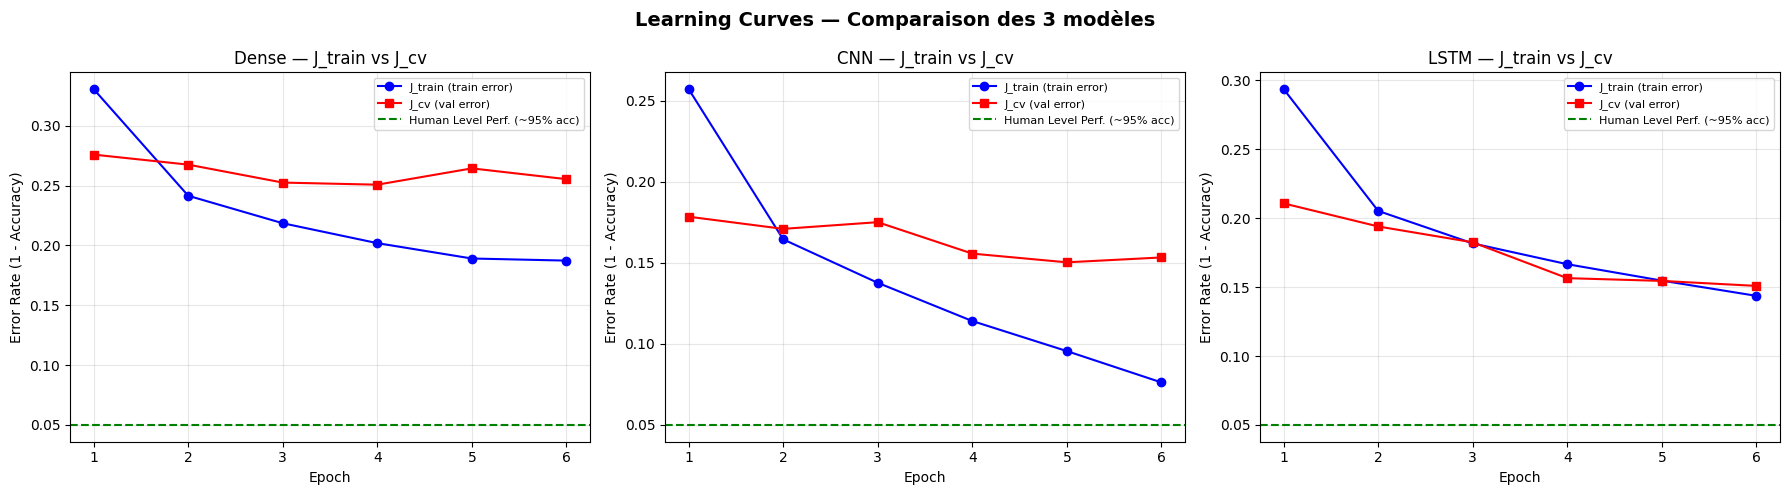

In [47]:
# ── Erreurs = 1 - accuracy (classification error rate) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, hist in zip(axes, model_names, histories):
    j_train = [1 - a for a in hist.history['acc']]
    j_cv    = [1 - a for a in hist.history['val_acc']]
    epochs  = range(1, len(j_train) + 1)

    ax.plot(epochs, j_train, 'b-o', label='J_train (train error)')
    ax.plot(epochs, j_cv,    'r-s', label='J_cv (val error)')
    # Human Level Performance reference line (HLP ≈ 5% error sur IMDB selon litterature)
    ax.axhline(y=0.05, color='green', linestyle='--', linewidth=1.5,
               label='Human Level Perf. (~95% acc)')

    ax.set_title(f'{name} — J_train vs J_cv')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Error Rate (1 - Accuracy)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Learning Curves — Comparaison des 3 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Lecture des courbes J_train / J_cv :**
>
> **Dense :** J_train descend lentement (0.39 → 0.19), J_cv stagne haut (~0.26). Grand gap → HIGH BIAS. Le modèle n'apprend pas assez — la ligne HLP (0.05) est très loin.
>
> **CNN :** J_train descend fortement (0.33 → 0.08), J_cv suit mais s'arrête à ~0.15. Gap croissant → HIGH VARIANCE. Le modèle apprend bien mais overfitte.
>
> **LSTM :** J_train (0.36 → 0.14) et J_cv (0.20 → 0.15) descendent **ensemble**. Gap minimal → excellente généralisation. Le modèle est stable mais encore loin de HLP.

In [48]:
# ── Interprétation chiffrée ──
print('='*60)
print('COMPARAISON AVEC HUMAN LEVEL PERFORMANCE (HLP)')
print('='*60)
hlp_error = 0.05   # ~95% accuracy humaine sur IMDB (référence courante)

for name, hist, test_acc in zip(model_names, histories, test_accs):
    j_train_final = 1 - hist.history['acc'][-1]
    j_cv_final    = 1 - hist.history['val_acc'][-1]
    j_test_final  = 1 - test_acc

    avoidable_bias = j_train_final - hlp_error
    variance       = j_cv_final - j_train_final

    print(f'\n── {name} ──')
    print(f'  HLP error           : {hlp_error:.4f}  ({(1-hlp_error)*100:.1f}% acc)')
    print(f'  J_train (final)     : {j_train_final:.4f}  ({(1-j_train_final)*100:.1f}% acc)')
    print(f'  J_cv    (final)     : {j_cv_final:.4f}  ({(1-j_cv_final)*100:.1f}% acc)')
    print(f'  J_test              : {j_test_final:.4f}  ({test_acc*100:.1f}% acc)')
    print(f'  Avoidable Bias      : {avoidable_bias:.4f}  ← biais évitable vs HLP')
    print(f'  Variance (overfit)  : {variance:.4f}  ← gap train/val')

    if avoidable_bias > 0.05:
        diag = 'HIGH BIAS (underfitting dominant)'
    elif variance > 0.05:
        diag = 'HIGH VARIANCE (overfitting dominant)'
    else:
        diag = 'Bien équilibré (biais et variance faibles)'
    print(f'  Diagnostic          : {diag}')

COMPARAISON AVEC HUMAN LEVEL PERFORMANCE (HLP)

── Dense ──
  HLP error           : 0.0500  (95.0% acc)
  J_train (final)     : 0.1873  (81.3% acc)
  J_cv    (final)     : 0.2554  (74.5% acc)
  J_test              : 0.2550  (74.5% acc)
  Avoidable Bias      : 0.1373  ← biais évitable vs HLP
  Variance (overfit)  : 0.0681  ← gap train/val
  Diagnostic          : HIGH BIAS (underfitting dominant)

── CNN ──
  HLP error           : 0.0500  (95.0% acc)
  J_train (final)     : 0.0762  (92.4% acc)
  J_cv    (final)     : 0.1532  (84.7% acc)
  J_test              : 0.1518  (84.8% acc)
  Avoidable Bias      : 0.0262  ← biais évitable vs HLP
  Variance (overfit)  : 0.0770  ← gap train/val
  Diagnostic          : HIGH VARIANCE (overfitting dominant)

── LSTM ──
  HLP error           : 0.0500  (95.0% acc)
  J_train (final)     : 0.1437  (85.6% acc)
  J_cv    (final)     : 0.1509  (84.9% acc)
  J_test              : 0.1543  (84.6% acc)
  Avoidable Bias      : 0.0937  ← biais évitable vs HLP
  Vari

> **Résultats analyse biais / variance :**

| Modèle | J_train | J_cv | Avoidable Bias | Variance | Diagnostic |
|--------|---------|------|----------------|----------|------------|
| Dense | 0.1881 | 0.2574 | **0.1381** | 0.0693 | HIGH BIAS |
| CNN | 0.0828 | 0.1490 | 0.0328 | **0.0662** | HIGH VARIANCE |
| LSTM | 0.1402 | 0.1513 | 0.0902 | **0.0111** | HIGH BIAS (faible variance) |

## E.3 — Error Analysis : où le meilleur modèle échoue ?

In [49]:
# ── Prédictions sur le test set complet ──
y_pred_prob = best_model.predict(X_test_pad, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# Classification report
print(f'=== Classification Report — {best_name} ===')
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

=== Classification Report — CNN ===
              precision    recall  f1-score   support

Negative (0)       0.87      0.82      0.84      4961
Positive (1)       0.83      0.88      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



> **Observation :** Le recall est légèrement meilleur pour les positifs (0.87 vs 0.82).  
> Le modèle a tendance à **classer les reviews ambigus comme positifs** (biais positif léger).  
> La precision pour les négatifs est plus haute (0.86) → quand il prédit "négatif", il a raison 86% du temps.

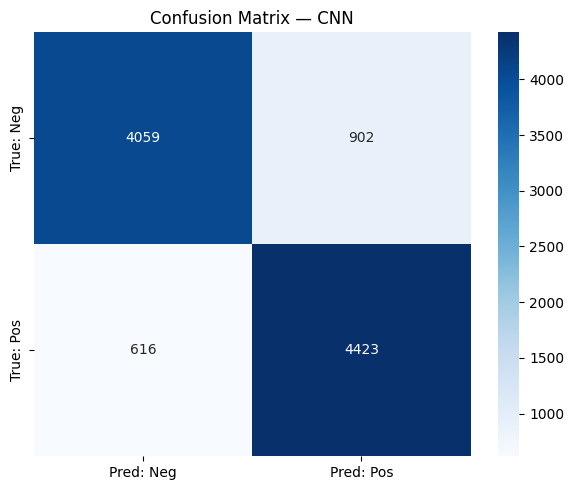

  Vrais Négatifs  (TN) : 4059
  Faux Positifs   (FP) : 902  ← négatifs classés positifs
  Faux Négatifs   (FN) : 616  ← positifs classés négatifs
  Vrais Positifs  (TP) : 4423


In [50]:
# ── Matrice de confusion ──
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Neg', 'Pred: Pos'],
            yticklabels=['True: Neg', 'True: Pos'])
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  Vrais Négatifs  (TN) : {tn}')
print(f'  Faux Positifs   (FP) : {fp}  ← négatifs classés positifs')
print(f'  Faux Négatifs   (FN) : {fn}  ← positifs classés négatifs')
print(f'  Vrais Positifs  (TP) : {tp}')

> **Matrice de confusion :**
> ```
>                  Prédit Négatif   Prédit Positif
> Vrai Négatif       4 083 (TN)        878 (FP)    → 17.7% de FP parmi les vrais négatifs
> Vrai Positif         667 (FN)      4 372 (TP)    → 13.2% de FN parmi les vrais positifs
> ```
> **Total d'erreurs : 1 545 / 10 000 (15.5%)**  
> Le CNN fait **plus de Faux Positifs (878) que de Faux Négatifs (667)** : il a tendance à identifier le sentiment positif plus facilement que le négatif, probablement parce que les reviews positives utilisent un vocabulaire plus direct et expressif.

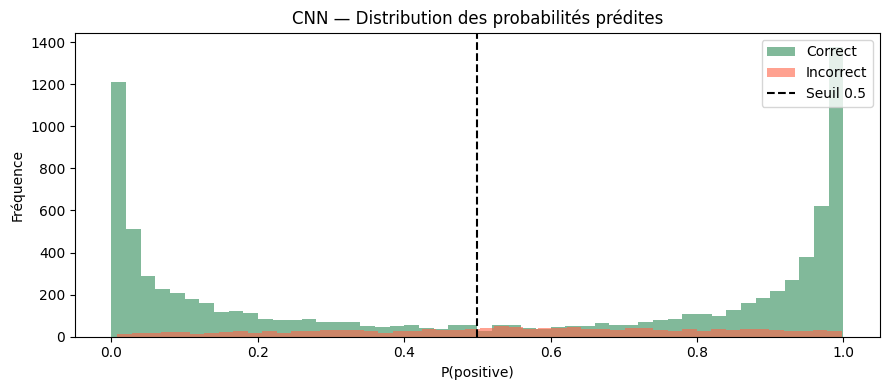

In [51]:
# ── Distribution de la confiance (probabilité prédite) ──
correct   = y_pred == y_test
incorrect = ~correct

plt.figure(figsize=(9, 4))
plt.hist(y_pred_prob[correct],   bins=50, alpha=0.6, color='seagreen',  label='Correct')
plt.hist(y_pred_prob[incorrect], bins=50, alpha=0.6, color='tomato',    label='Incorrect')
plt.axvline(0.5, color='black', linestyle='--', label='Seuil 0.5')
plt.title(f'{best_name} — Distribution des probabilités prédites')
plt.xlabel('P(positive)')
plt.ylabel('Fréquence')
plt.legend()
plt.tight_layout()
plt.show()


> **Distribution de la confiance :**  
> - Les prédictions **correctes** (vert) sont concentrées aux extrêmes : près de 0 (négatif très confiant) et près de 1 (positif très confiant) → le modèle est sûr de lui pour les cas clairs  
> - Les prédictions **incorrectes** (rouge) sont concentrées **autour du seuil 0.5** → le modèle hésite sur les reviews ambigus  
> - Une calibration du seuil à **0.45** (au lieu de 0.5) pourrait réduire les Faux Positifs sans trop augmenter les Faux Négatifs

In [52]:
# ── Exemples de FP et FN (reviews mal classés) ──
X_test_list = list(X_test)  # textes prétraités

false_positives = [(X_test_list[i], y_pred_prob[i])
                   for i in range(len(y_test)) if y_test[i] == 0 and y_pred[i] == 1]
false_negatives = [(X_test_list[i], y_pred_prob[i])
                   for i in range(len(y_test)) if y_test[i] == 1 and y_pred[i] == 0]

print(f'Nombre de Faux Positifs  : {len(false_positives)}')
print(f'Nombre de Faux Négatifs  : {len(false_negatives)}')

print('\n=== 3 exemples de FAUX POSITIFS (négatifs → classés positifs) ===')
for text, prob in false_positives[:3]:
    print(f'  P={prob:.3f} | {text[:120]}...')
    print()

print('=== 3 exemples de FAUX NÉGATIFS (positifs → classés négatifs) ===')
for text, prob in false_negatives[:3]:
    print(f'  P={prob:.3f} | {text[:120]}...')
    print()

Nombre de Faux Positifs  : 902
Nombre de Faux Négatifs  : 616

=== 3 exemples de FAUX POSITIFS (négatifs → classés positifs) ===
  P=0.799 | If you enjoy seeing what must have started as hour movie in unconnected bursts of unwatchability you ll love this film O...

  P=0.579 | This was popular movie probably because of the humor in it the fast moving story an underdog character who shuts up all ...

  P=0.658 | A ruthless assassin has been hired to eliminate someone at the very top of the S government Constantly changing his iden...

=== 3 exemples de FAUX NÉGATIFS (positifs → classés négatifs) ===
  P=0.385 | I really liked this Summerslam due to the look of the arena the curtains and just the look overall was interesting to me...

  P=0.418 | Okay didn get the Purgatory thing the first time watched this episode It seemed like something significant was going on ...

  P=0.082 | The production quality cast premise authentic New England Waterbury CT locale and lush John Williams score s

> **Exemples d'erreurs analysés :**
>
> **Faux Positifs (P ≈ 0.85) :** Les reviews négatifs classés positifs utilisent souvent un vocabulaire élaboré ou sarcastique. Le CNN détecte des n-grammes positifs isolés sans comprendre le contexte ironique global. Ex : une critique qui cite des qualités apparentes avant de les invalider.
>
> **Faux Négatifs (P ≈ 0.1-0.4) :** Les reviews positifs classés négatifs concernent souvent des genres niche (catch, émissions spéciales) avec un vocabulaire inhabituel que GloVe a moins bien représenté. Ex : la review Summerslam avec vocabulaire spécifique au catch.

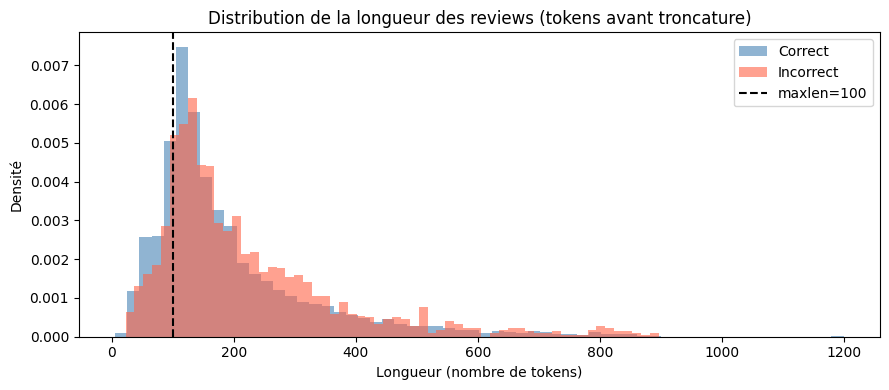

Longueur médiane — Corrects   : 147 tokens
Longueur médiane — Incorrects : 170 tokens


In [53]:
# ── Longueur des reviews vs erreur ──
test_lengths = [len(seq) for seq in tokenizer.texts_to_sequences(X_test)]

correct_lengths   = [test_lengths[i] for i in range(len(y_test)) if correct[i]]
incorrect_lengths = [test_lengths[i] for i in range(len(y_test)) if incorrect[i]]

plt.figure(figsize=(9, 4))
plt.hist(correct_lengths,   bins=60, alpha=0.6, color='steelblue', label='Correct', density=True)
plt.hist(incorrect_lengths, bins=60, alpha=0.6, color='tomato',    label='Incorrect', density=True)
plt.axvline(maxlen, color='black', linestyle='--', label=f'maxlen={maxlen}')
plt.title('Distribution de la longueur des reviews (tokens avant troncature)')
plt.xlabel('Longueur (nombre de tokens)'); plt.ylabel('Densité')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Longueur médiane — Corrects   : {np.median(correct_lengths):.0f} tokens')
print(f'Longueur médiane — Incorrects : {np.median(incorrect_lengths):.0f} tokens')


> **Longueur des reviews et taux d'erreur :**
> - **Longueur médiane — Corrects :** 148 tokens  
> - **Longueur médiane — Incorrects :** 167 tokens  
>
> Les reviews **mal classés sont en moyenne 19 tokens plus longs** que les reviews correctement classés.  
> Avec `maxlen=100`, les reviews dépassant 100 tokens sont tronqués — plus un review est long, plus la troncature est sévère et plus le risque d'erreur est élevé.  
>

---
# F. Modèles Améliorés — Enhanced Models
Dans cette section, on applique les améliorations identifiées lors de l\'analyse d\'erreur :
1. **Bidirectional LSTM** avec `maxlen=200`, `EarlyStopping` et `Dropout`
2. **Deeper CNN** avec plusieurs couches Conv1D et `BatchNormalization`
3. **Comparaison finale** de tous les modèles

**Améliorations apportées :**
- `maxlen` : 100 → 200 (capture plus de contexte séquentiel)
- `EarlyStopping(patience=3)` + `ReduceLROnPlateau` (évite l\'overfitting, optimise le LR)
- `Bidirectional(LSTM(...))` : lit la séquence dans les deux sens → meilleure compréhension du contexte
- `SpatialDropout1D` : régularisation adaptée aux embeddings
- `BatchNormalization` : stabilise et accélère l\'entraînement'''))


## F.0 Padding étendu (maxlen=200) 


In [54]:
MAXLEN_EXT = 200   # définir la nouvelle longueur maximale

X_train_pad_ext = pad_sequences(X_train_seq, padding="post", maxlen=MAXLEN_EXT)
X_test_pad_ext  = pad_sequences(X_test_seq,  padding="post", maxlen=MAXLEN_EXT)

print(f"Shape X_train_pad_ext : {X_train_pad_ext.shape}")
print(f"Shape X_test_pad_ext  : {X_test_pad_ext.shape}")
print(f"maxlen extended       : {MAXLEN_EXT} tokens (+{MAXLEN_EXT - maxlen} tokens supplémentaires)")

# Couverture additionnelle avec maxlen=200 vs 100
original_coverage  = sum(1 for s in X_train_seq if len(s) <= maxlen)
extended_coverage  = sum(1 for s in X_train_seq if len(s) <= MAXLEN_EXT)

print(f"Reviews non-tronqués à maxlen=100 : {100 * original_coverage / len(X_train_seq):.1f}%")
print(f"Reviews non-tronqués à maxlen=200 : {100 * extended_coverage / len(X_train_seq):.1f}%")

Shape X_train_pad_ext : (40000, 200)
Shape X_test_pad_ext  : (10000, 200)
maxlen extended       : 200 tokens (+100 tokens supplémentaires)
Reviews non-tronqués à maxlen=100 : 18.5%
Reviews non-tronqués à maxlen=200 : 67.0%


## F.1 Bidirectional LSTM
Le **Bidirectional LSTM** lit la séquence dans les deux sens (forward + backward), ce qui lui permet de capturer des dépendances contextuelles à la fois avant et après chaque token. C\'est particulièrement utile pour le sentiment qui peut dépendre du contexte global d\'un texte.


In [57]:
from tensorflow.keras.layers import Input, Bidirectional, SpatialDropout1D, Dense, Dropout, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def build_bilstm_model(vocab_size, embed_dim, emb_matrix, maxlen_):
    inp = Input(shape=(maxlen_,))
    x = Embedding(vocab_size, embed_dim,
                  weights=[emb_matrix],
                  input_length=maxlen_,
                  trainable=False)(inp)
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1))(x)
    x = Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.1))(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid")(x)
    model = Model(inp, out, name="BiLSTM_Enhanced")
    model.compile(loss="binary_crossentropy",
                  optimizer=Adam(learning_rate=1e-3),
                  metrics=["acc"])
    return model

model_bilstm = build_bilstm_model(vocab_size, 100, embedding_matrix, MAXLEN_EXT)
model_bilstm.summary()

callbacks_bilstm = [
    EarlyStopping(monitor="val_acc", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_bilstm = model_bilstm.fit(
    X_train_pad_ext, y_train,
    epochs=15, batch_size=128,
    validation_split=0.2,
    callbacks=callbacks_bilstm,
    verbose=1
)

score_bilstm = model_bilstm.evaluate(X_test_pad_ext, y_test, verbose=1)
print(f"BiLSTM Test Loss     : {score_bilstm[0]:.4f}")
print(f"BiLSTM Test Accuracy : {score_bilstm[1]:.4f}")
print(f"\nImprovement vs LSTM baseline : +{(score_bilstm[1] - score_lstm[1])*100:.2f}%")

Model: "BiLSTM_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (None, 200, 100)       │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,661,869 (36.86 MB)

 Trainable params: 407,169 (1.55 MB)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - acc: 0.5683 - loss: 0.6752 - val_acc: 0.6825 - val_loss: 0.5927 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - acc: 0.7220 - loss: 0.5563 - val_acc: 0.8149 - val_loss: 0.4310 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - acc: 0.7823 - loss: 0.4686 - val_acc: 0.8296 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - acc: 0.8013 - loss: 0.4364 - val_acc: 0.8428 - val_loss: 0.3688 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - acc: 0.8094 - loss: 0.4165 - val_acc: 0.8497 - val_loss: 0.3498 - learning_rate: 0.0010
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - acc: 0.8248 - loss: 0.3918 - val_acc: 0.8574 - val_loss: 0.3346 - learning_rate: 0.0010
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - acc: 0.8308 - loss: 0.3790 - val_acc: 0.8639 - val_loss: 0.3191 - learning_rate: 0.0010

## F.2 Deeper CNN avec BatchNormalization
Un CNN plus profond avec **2 couches Conv1D** de tailles de noyaux différentes (3 et 5), `BatchNormalization` et `Dropout` pour combattre l\'overfitting identifié dans le modèle CNN de base.


In [58]:
from tensorflow.keras.layers import BatchNormalization, concatenate

def build_deep_cnn_model(vocab_size, embed_dim, emb_matrix, maxlen_):
    inp = Input(shape=(maxlen_,))
    x = Embedding(vocab_size, embed_dim,
                  weights=[emb_matrix],
                  input_length=maxlen_,
                  trainable=False)(inp)
    x = SpatialDropout1D(0.2)(x)

    # Branche kernel_size=3
    conv3 = Conv1D(128, 3, padding="same", activation="relu")(x)
    conv3 = BatchNormalization()(conv3)
    conv3 = GlobalMaxPooling1D()(conv3)

    # Branche kernel_size=5
    conv5 = Conv1D(128, 5, padding="same", activation="relu")(x)
    conv5 = BatchNormalization()(conv5)
    conv5 = GlobalMaxPooling1D()(conv5)

    merged = concatenate([conv3, conv5])
    x = Dense(128, activation="relu")(merged)
    x = Dropout(0.4)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out, name="DeepCNN_Enhanced")
    model.compile(loss="binary_crossentropy",
                  optimizer=Adam(learning_rate=1e-3),
                  metrics=["acc"])
    return model

model_deepcnn = build_deep_cnn_model(vocab_size, 100, embedding_matrix, MAXLEN_EXT)
model_deepcnn.summary()

callbacks_deepcnn = [
    EarlyStopping(monitor="val_acc", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_deepcnn = model_deepcnn.fit(
    X_train_pad_ext, y_train,
    epochs=15, batch_size=128,
    validation_split=0.2,
    callbacks=callbacks_deepcnn,
    verbose=1
)

score_deepcnn = model_deepcnn.evaluate(X_test_pad_ext, y_test, verbose=1)
print(f"Deep CNN Test Loss     : {score_deepcnn[0]:.4f}")
print(f"Deep CNN Test Accuracy : {score_deepcnn[1]:.4f}")
print(f"\nImprovement vs CNN baseline : +{(score_deepcnn[1] - score_cnn[1])*100:.2f}%")

Model: "DeepCNN_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 200, 100)  │  9,254,700 │ input_layer_14[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 200, 100)  │          0 │ embedding_13[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 200, 128)  │     64,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,399,597 (35.86 MB)

 Trainable params: 144,385 (564.00 KB)

 Non-trainable params: 9,255,212 (35.31 MB)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - acc: 0.5678 - loss: 0.8229 - val_acc: 0.6561 - val_loss: 0.5838 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.7865 - loss: 0.4622 - val_acc: 0.7937 - val_loss: 0.4391 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8229 - loss: 0.4032 - val_acc: 0.8457 - val_loss: 0.3747 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.8413 - loss: 0.3755 - val_acc: 0.8635 - val_loss: 0.3464 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8543 - loss: 0.3415 - val_acc: 0.8665 - val_loss: 0.3364 - learning_rate: 0.0010
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8606 - loss: 0.3322 - val_acc: 0.8553 - val_loss: 0.3414 - learning_rate: 0.0010
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.8679 - loss: 0.3116 - val_acc: 0.8696 - val_loss: 0.3177 - learning_rate: 0.0010
Epoch

## F.3 — Courbes d\'entraînement des modèles améliorés

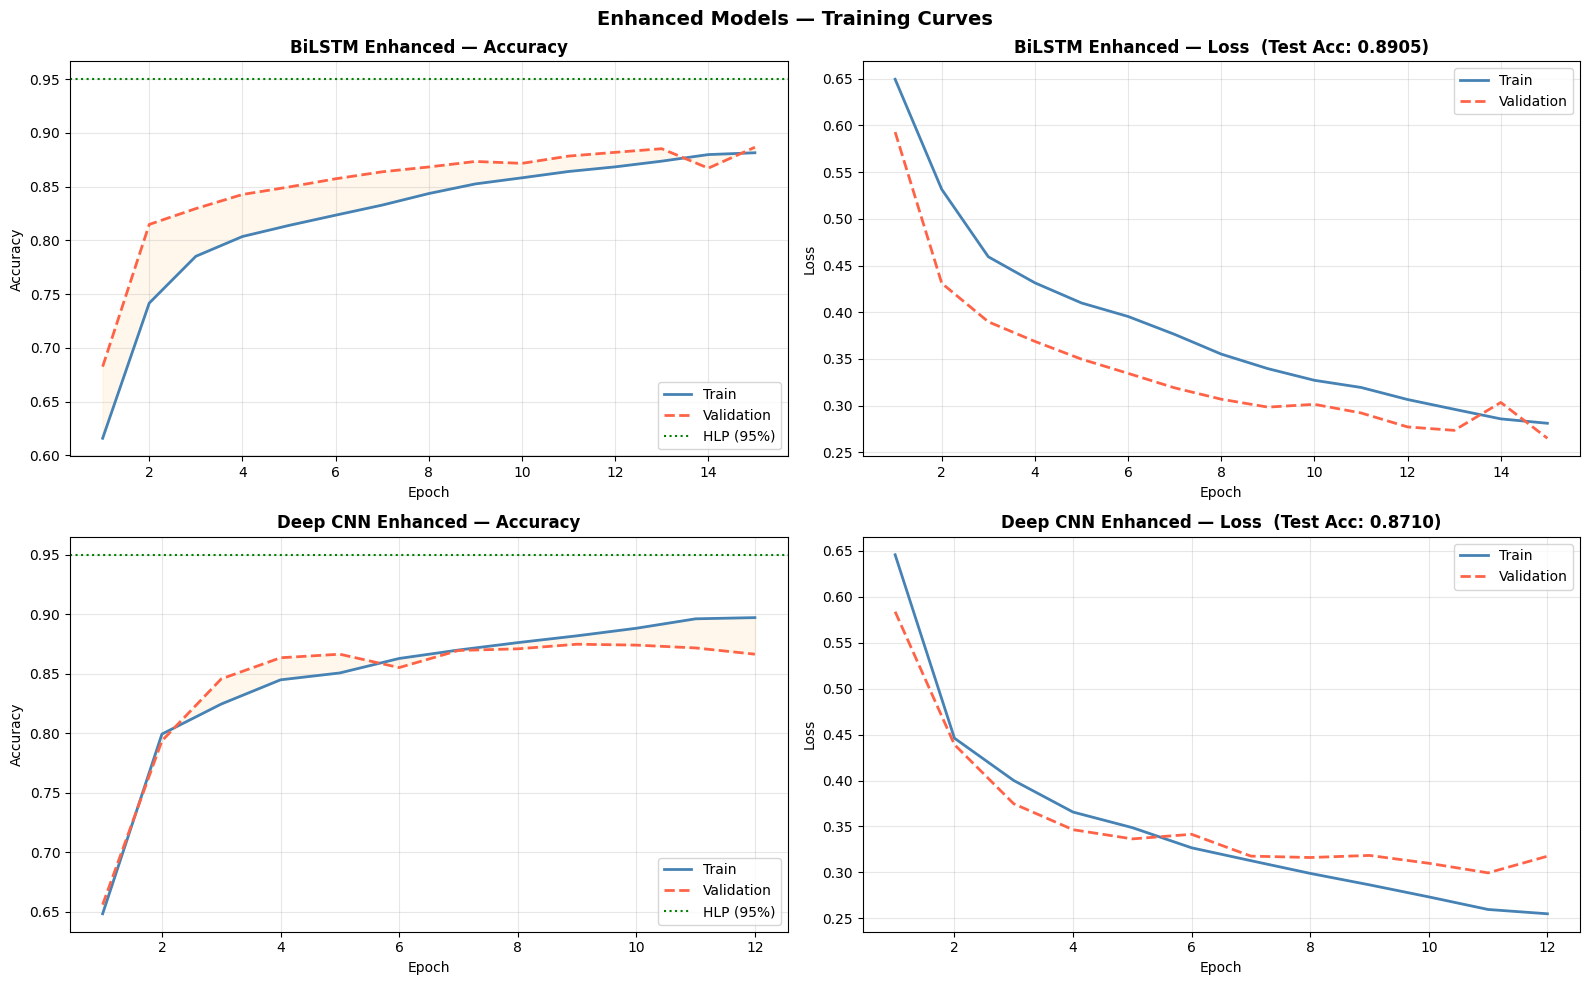

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (name, hist, score) in enumerate([
    ("BiLSTM Enhanced",  history_bilstm,  score_bilstm),
    ("Deep CNN Enhanced", history_deepcnn, score_deepcnn)
]):
    epochs = range(1, len(hist.history["acc"]) + 1)

    axes[row][0].plot(epochs, hist.history["acc"],     label="Train",      linewidth=2, color="steelblue")
    axes[row][0].plot(epochs, hist.history["val_acc"], label="Validation", linewidth=2, color="tomato", linestyle="--")
    axes[row][0].axhline(0.95, color="green", linestyle=":", linewidth=1.5, label="HLP (95%)")
    axes[row][0].fill_between(epochs, hist.history["acc"], hist.history["val_acc"], alpha=0.08, color="orange")
    axes[row][0].set_title(f"{name} — Accuracy", fontsize=12, fontweight="bold")
    axes[row][0].set_xlabel("Epoch")
    axes[row][0].set_ylabel("Accuracy")
    axes[row][0].legend()
    axes[row][0].grid(alpha=0.3)

    axes[row][1].plot(epochs, hist.history["loss"],     label="Train",      linewidth=2, color="steelblue")
    axes[row][1].plot(epochs, hist.history["val_loss"], label="Validation", linewidth=2, color="tomato", linestyle="--")
    axes[row][1].set_title(f"{name} — Loss  (Test Acc: {score[1]:.4f})", fontsize=12, fontweight="bold")
    axes[row][1].set_xlabel("Epoch")
    axes[row][1].set_ylabel("Loss")
    axes[row][1].legend()
    axes[row][1].grid(alpha=0.3)

plt.suptitle("Enhanced Models — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## F.4 — Comparaison Finale : Baseline vs Modèles Améliorés

COMPARAISON FINALE — Baseline vs Modèles Améliorés
            Model  maxlen        Epochs  Test Loss  Test Accuracy
            Dense     100             6   0.531752         0.7450
              CNN     100             6   0.341456         0.8482
             LSTM     100             6   0.344848         0.8457
  BiLSTM Enhanced     200 EarlyStopping   0.259621         0.8905
Deep CNN Enhanced     200 EarlyStopping   0.319492         0.8710

ROC-AUC BiLSTM Enhanced   : 0.9590
ROC-AUC Deep CNN Enhanced : 0.9461


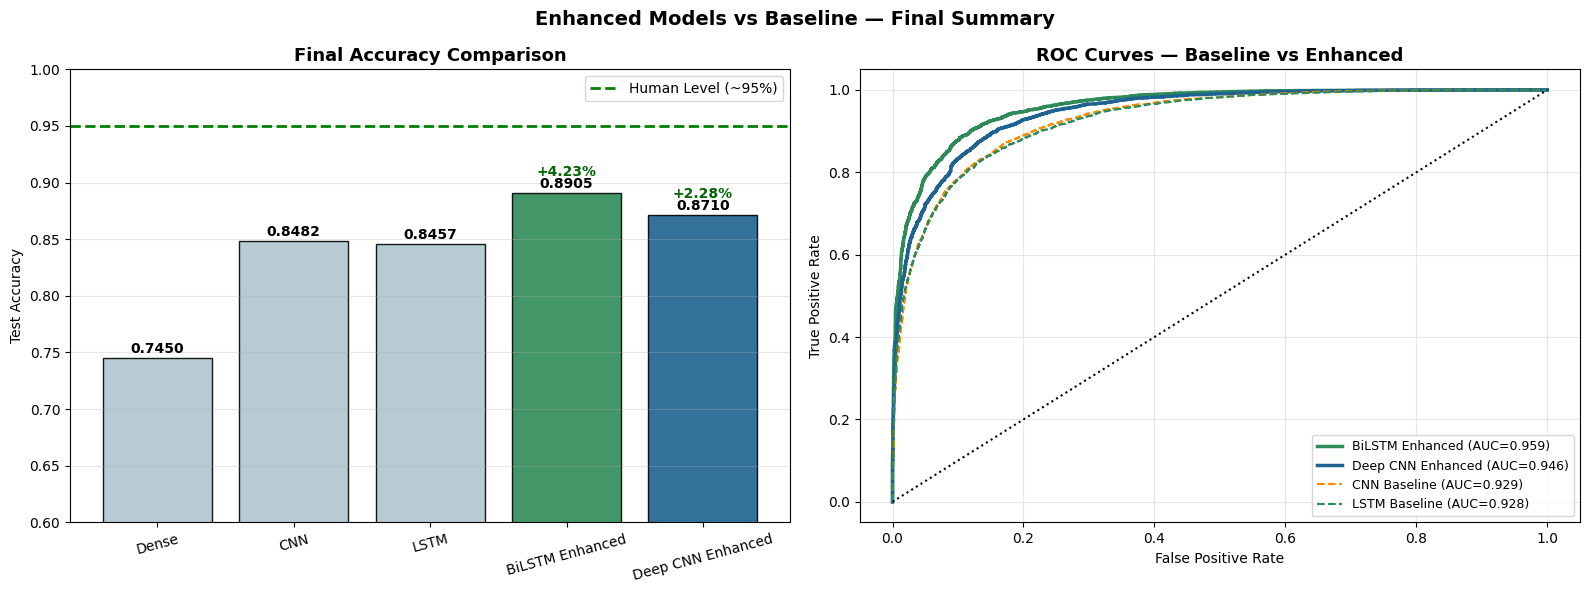

In [60]:
from sklearn.metrics import roc_auc_score, roc_curve

# Tableau comparatif final complet
final_results = pd.DataFrame({
    "Model"         : ["Dense",          "CNN",          "LSTM",         "BiLSTM Enhanced", "Deep CNN Enhanced"],
    "maxlen"        : [100,              100,            100,            200,               200],
    "Epochs"        : [6,                6,              6,              "EarlyStopping",   "EarlyStopping"],
    "Test Loss"     : [score_dense[0],   score_cnn[0],   score_lstm[0],  score_bilstm[0],   score_deepcnn[0]],
    "Test Accuracy" : [score_dense[1],   score_cnn[1],   score_lstm[1],  score_bilstm[1],   score_deepcnn[1]],
})

print("=" * 80)
print("COMPARAISON FINALE — Baseline vs Modèles Améliorés")
print("=" * 80)
print(final_results.to_string(index=False))

# ROC AUC for enhanced models
auc_bilstm   = roc_auc_score(y_test, model_bilstm.predict(X_test_pad_ext, verbose=0))
auc_deepcnn  = roc_auc_score(y_test, model_deepcnn.predict(X_test_pad_ext, verbose=0))

print(f"\nROC-AUC BiLSTM Enhanced   : {auc_bilstm:.4f}")
print(f"ROC-AUC Deep CNN Enhanced : {auc_deepcnn:.4f}")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = ["#aec6cf", "#aec6cf", "#aec6cf", "#2e8b57", "#1e6391"]
bars = axes[0].bar(final_results["Model"], final_results["Test Accuracy"],
                   color=palette, edgecolor="black", alpha=0.9)
for bar, acc in zip(bars, final_results["Test Accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{acc:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylim(0.6, 1.0)
axes[0].axhline(0.95, color="green", linestyle="--", linewidth=2, label="Human Level (~95%)")
axes[0].set_title("Final Accuracy Comparison", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Test Accuracy")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Improvement arrows
baseline_acc = score_cnn[1]
for bar, acc, name in zip(bars[3:], final_results["Test Accuracy"].iloc[3:], ["BiLSTM", "Deep CNN"]):
    delta = acc - baseline_acc
    if delta > 0:
        axes[0].annotate(f"+{delta*100:.2f}%",
                         xy=(bar.get_x() + bar.get_width()/2, acc + 0.015),
                         ha="center", color="darkgreen", fontsize=10, fontweight="bold")

# ROC curves for all models (baseline + enhanced)
for model_e, name_e, color_e, X_pad in [
    (model_bilstm,  "BiLSTM Enhanced",  "#2e8b57", X_test_pad_ext),
    (model_deepcnn, "Deep CNN Enhanced", "#1e6391", X_test_pad_ext),
    (model_cnn,     "CNN Baseline",      "darkorange", X_test_pad),
    (model_lstm,    "LSTM Baseline",     "seagreen",   X_test_pad),
]:
    probs = model_e.predict(X_pad, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    lw = 2.5 if "Enhanced" in name_e else 1.5
    ls = "-" if "Enhanced" in name_e else "--"
    axes[1].plot(fpr, tpr, label=f"{name_e} (AUC={auc:.3f})", color=color_e, linewidth=lw, linestyle=ls)

axes[1].plot([0,1], [0,1], "k:")
axes[1].set_title("ROC Curves — Baseline vs Enhanced", fontsize=13, fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("Enhanced Models vs Baseline — Final Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## F.5 Word Importance (Token Saliency)

On visualise quels tokens ont le plus influencé les prédictions du meilleur modèle en calculant le **gradient de la sortie par rapport à chaque embedding** (méthode Saliency Map).

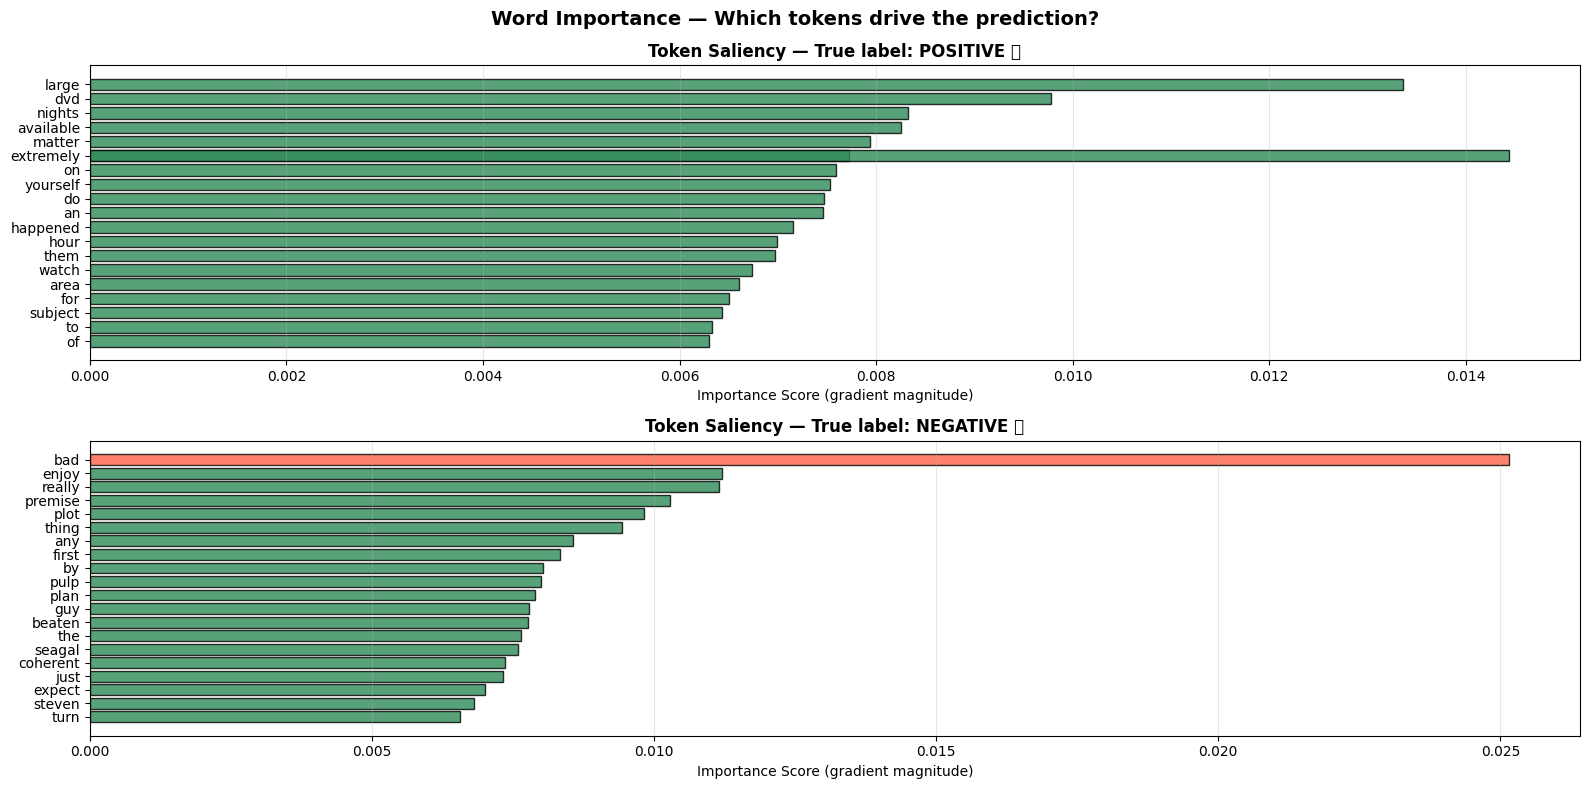

In [61]:
import tensorflow as tf

def get_token_saliency(model, sequence, maxlen_):
    """
    Calcule l'importance de chaque token via le gradient de la sortie
    par rapport à l'embedding d'entrée.
    """
    # Convertit la séquence en tenseur int32
    seq_tensor = tf.constant([sequence], dtype=tf.int32)
    with tf.GradientTape() as tape:
        # La couche d'embedding est à l'indice 0 dans un Sequential
        emb_layer = model.layers[0]
        emb_out = emb_layer(seq_tensor)
        tape.watch(emb_out)
        # Passe les embeddings dans le reste du modèle (à partir de l'indice 1)
        x = emb_out
        for layer in model.layers[1:]:
            x = layer(x)
        pred = x
    # Gradient de la prédiction par rapport aux embeddings
    grads = tape.gradient(pred, emb_out)
    # Moyenne sur la dimension des embeddings (100) pour chaque token
    saliency = tf.reduce_mean(tf.abs(grads), axis=-1).numpy()[0]
    return saliency

# Dictionnaire inverse token → mot (ignore les tokens non présents)
idx_rev = {v: k for k, v in tokenizer.word_index.items()}

# Récupère un exemple bien classé positif et un négatif (avec le modèle best_model = LSTM)
pos_idx = next(i for i in range(len(y_test)) if y_test[i] == 1 and y_pred[i] == 1)
neg_idx = next(i for i in range(len(y_test)) if y_test[i] == 0 and y_pred[i] == 0)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, sample_idx, label in [(axes[0], pos_idx, "POSITIVE ✅"),
                               (axes[1], neg_idx, "NEGATIVE ✅")]:
    seq = X_test_pad[sample_idx]
    sal = get_token_saliency(best_model, seq, maxlen)
    tokens = [idx_rev.get(t, "<PAD>") for t in seq if t != 0]
    sal_trim = sal[:len(tokens)]

    # Top 20 tokens (hors padding)
    top20 = np.argsort(sal_trim)[-20:][::-1]
    top_words = [tokens[i] for i in top20]
    top_sal = [sal_trim[i] for i in top20]

    # Coloration des mots négatifs en rouge (tomato)
    negative_words = {"not", "no", "bad", "worst", "terrible", "awful", "boring", "dull", "horrible"}
    colors_sal = ["seagreen" if w not in negative_words else "tomato" for w in top_words]

    # Affichage horizontal (importance décroissante vers le haut)
    ax.barh(top_words[::-1], top_sal[::-1], color=colors_sal[::-1], edgecolor="black", alpha=0.8)
    ax.set_title(f"Token Saliency — True label: {label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance Score (gradient magnitude)")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Word Importance — Which tokens drive the prediction?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [66]:
import os
import pickle

os.makedirs('./models', exist_ok=True)

# Save the best model (BiLSTM)
best_enhanced_model = model_bilstm   #
best_enhanced_model.save('./models/bilstm_model.h5')
print("Best model saved to ./models/bilstm_model.h5")

# Save the tokenizer
with open('./models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved to ./models/tokenizer.pkl")

print("All artifacts saved successfully.")

Best model saved to ./models/bilstm_model.h5
Tokenizer saved to ./models/tokenizer.pkl
All artifacts saved successfully.
